guide = https://www.youtube.com/watch?v=RHGiXPuo_pI&list=PLblh5JKOoLUIxGDQs4LFFD--41Vzf-ME1&index=31&t=8s

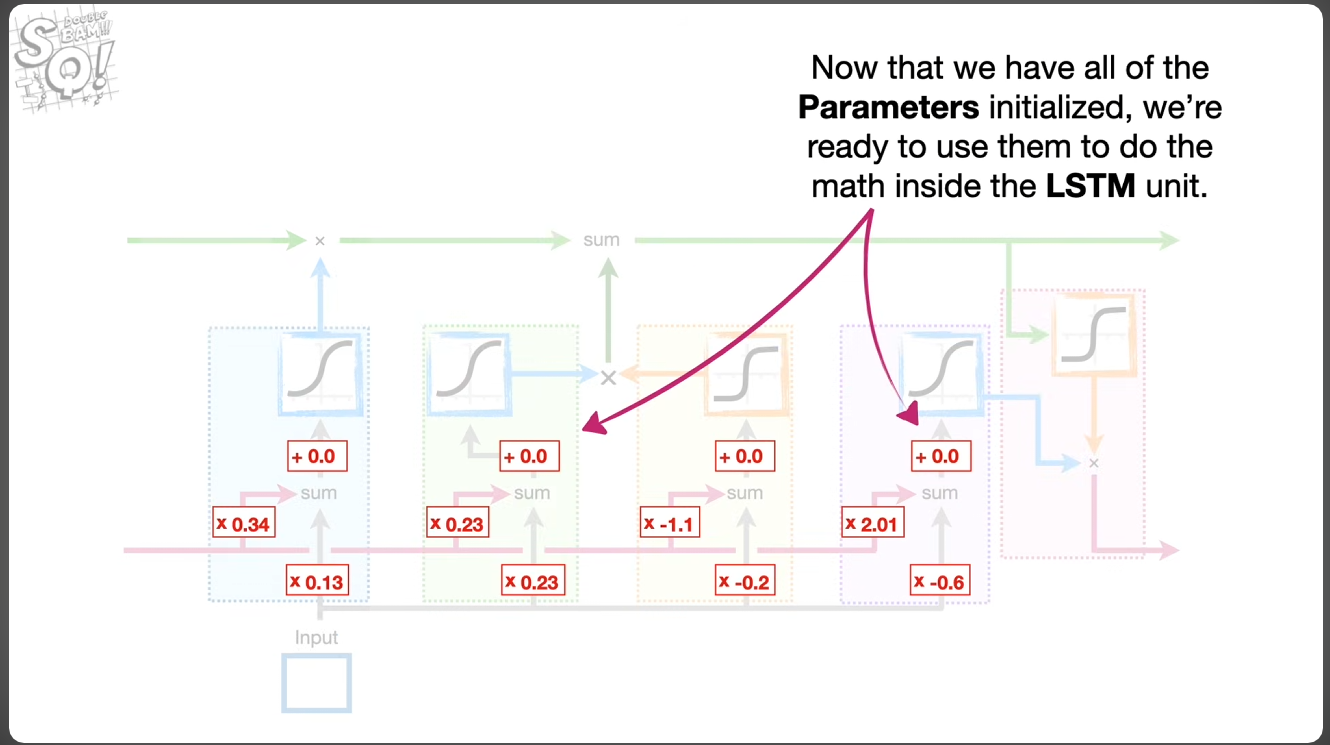

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torch.optim import Adam

import lightning as L 
from lightning.pytorch.loggers import TensorBoardLogger
from torch.utils.data import TensorDataset, DataLoader

tb_logger = TensorBoardLogger(
    save_dir="lightning_logs",
    name="lightning_nn"
)

W0719 09:37:24.975000 39224 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
torch.cuda.is_available()

True

# LSTM BY HAND


In [ ]:
class LSTMbyHand(L.LightningModule):

    def __init__(self):
        super().__init__()

        # using standard deviation to generate intial weights and biases 
        mean = torch.tensor(0.0)
        std = torch.tensor(1.0)
        torch.manual_seed(42)

        # FORGET GATE 
        self.wlr1 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True) # WEIGT LONG-TERM to REMEMBER
        self.wlr2 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)
        self.blr1 = nn.Parameter(torch.tensor(0.), requires_grad=True)

        # INPUT GATE 
        self.wpr1 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True) # Percentage to Remember
        self.wpr2 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)
        self.bpr1 = nn.Parameter(torch.tensor(0.), requires_grad=True)
        
        self.wpl1 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)   #Potential Long Term memory
        self.wpl2 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)
        self.bpl1 = nn.Parameter(torch.tensor(0.), requires_grad=True)

        # OUTPUT GATE 
        self.wo1 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)
        self.wo2 = nn.Parameter(torch.normal(mean=mean, std=std), requires_grad=True)
        self.bo1 = nn.Parameter(torch.tensor(0.), requires_grad=True)


    def lstm_unit(self, input_value, long_memory, short_memory):
        # FORGET GATE 
        long_remember_percent = torch.sigmoid((short_memory*self.wlr1) + 
                                              (input_value * self.wlr2) + 
                                              self.blr1
                                              )
        
        # INPUT GATE
        potential_remember_percent = torch.sigmoid((short_memory * self.wpr1)+ 
                                                   (input_value * self.wpr2)+
                                                   self.bpr1
                                                   )
        
        potential_long_memory = torch.tanh((short_memory * self.wpl1)+
                                           (input_value * self.wpl2)+
                                           self.bpl1)
        
        updated_long_memory = (long_memory * long_remember_percent)+(potential_long_memory * potential_remember_percent)
        
        # OUTPUT GATE

        output_percent = torch.sigmoid((short_memory * self.wo1)+
                                (input_value * self.wo2)+
                                self.bo1
                                )

        updated_short_memory = torch.tanh(updated_long_memory) * output_percent

        return([updated_long_memory, updated_short_memory])
    
    def forward(self, input):
        long_memory = 0
        short_memory = 0 

        for i in input : 
            long_memory, short_memory = self.lstm_unit(i, long_memory, short_memory)
        return short_memory
    
    def configure_optimizers(self):
        return Adam(self.parameters())
    
    def training_step(self,batch, batch_idx):
        
        images, labels = batch
        logits = self.forward(images)

        loss = (logits - labels)**2
        predictions = logits.argmax(dim=1)
        accuracy = (predictions == labels).float().mean()

        self.log(
            "train_loss",
            loss,
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

        self.log(
            "train_accuracy",
            accuracy,
            on_step=False,
            on_epoch=True,
            # prog_bar=True,
            batch_size=images.size(0),
        )


        return loss 

In [31]:
model = LSTMbyHand()

In [32]:

data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


print("\n NOW LETS COMPARE THE OBSERVED AND PREDICTED VALUES BEFORE FITTING")

print("COMPANY A: OBSERVED = 0, predicted =", model(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model(data_b).detach())


 NOW LETS COMPARE THE OBSERVED AND PREDICTED VALUES BEFORE FITTING
COMPANY A: OBSERVED = 0, predicted = tensor(-0.0377)
COMPANY B: OBSERVED = 1, predicted = tensor(-0.0383)


## 1st Fit 

In [33]:
# CRETING TRAINING DATA 

inputs = torch.tensor([[0., 0.5, 0.25, 1.],
                       [1., 0.5, 0.25, 1.]])
labels = torch.tensor([0., 1.])
     

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

In [34]:
trainer = L.Trainer(max_epochs = 2000, accelerator="gpu", devices="auto")
# tuner = L.pytorch.tuner.Tuner(trainer)

trainer.fit(model, train_dataloaders=dataloader)
print(type(trainer.logger).__name__)
print(trainer.log_dir)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type | Params | Mode | FLOPs
-----------------------------------------------------
  | other params | n/a  | 12     | n/a  | n/a  
-----------------------------------------------------
12        Trainable params
0         Non-trainable params
12        Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 1999: 100%|██████████| 2/2 [00:00<00:00, 105.37it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 2/2 [00:00<00:00, 74.90it/s, v_num=0] 
TensorBoardLogger
c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\Pytorch\lightning_logs\version_0


In [36]:
# RESULT AFTER 1st FIT 

data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


# print("\n NOW LETS COMPARE THE OBSERVED AND PREDICTED VALUES BEFORE FITTING")

print("COMPANY A: OBSERVED = 0, predicted =", model(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model(data_b).detach())

COMPANY A: OBSERVED = 0, predicted = tensor(0.4342)
COMPANY B: OBSERVED = 1, predicted = tensor(0.6171)


## ADDING EPOCHS WITHOUT RESTARTING

In [37]:
path_to_best_checkpoint = trainer.checkpoint_callback.best_model_path

In [38]:

trainer = L.Trainer(max_epochs=3000)
trainer.fit(model, train_dataloaders=dataloader, ckpt_path=path_to_best_checkpoint)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\Pytorch\lightning_logs\version_0\checkpoints\epoch=1999-step=4000.ckpt
c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:566: The dirpath has changed from 'c:\\Users\\ESHAAN\\Documents\\Ideaverse Lite 1.5\\ML - Code\\Pytorch\\lightning_logs\\version_0\\checkpoints' to 'c:\\Users\\ESHAAN\\Documents\\Ideavers

Epoch 2999: 100%|██████████| 2/2 [00:00<00:00, 113.39it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 2999: 100%|██████████| 2/2 [00:00<00:00, 75.93it/s, v_num=1] 


In [29]:
data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


print("\n AFTER ADDING 1000 epochs")

print("COMPANY A: OBSERVED = 0, predicted =", model(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model(data_b).detach())


 AFTER ADDING 1000 epochs
COMPANY A: OBSERVED = 0, predicted = tensor(0.2708)
COMPANY B: OBSERVED = 1, predicted = tensor(0.7534)


In [40]:
# adding more epochs

path_to_best_checkpoint = trainer.checkpoint_callback.best_model_path

trainer = L.Trainer(max_epochs=5000)
trainer.fit(model,train_dataloaders=dataloader, ckpt_path=path_to_best_checkpoint)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\Pytorch\lightning_logs\version_1\checkpoints\epoch=2999-step=6000.ckpt
c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:566: The dirpath has changed from 'c:\\Users\\ESHAAN\\Documents\\Ideaverse Lite 1.5\\ML - Code\\Pytorch\\lightning_logs\\version_1\\checkpoints' to 'c:\\Users\\ESHAAN\\Documents\\Ideavers

Epoch 4999: 100%|██████████| 2/2 [00:00<00:00, 81.34it/s, v_num=2] 

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|██████████| 2/2 [00:00<00:00, 62.47it/s, v_num=2]


In [41]:
data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


print("\n AFTER ADDING ANOTHER 2000 epochs")

print("COMPANY A: OBSERVED = 0, predicted =", model(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model(data_b).detach())


 AFTER ADDING ANOTHER 2000 epochs
COMPANY A: OBSERVED = 0, predicted = tensor(0.0022)
COMPANY B: OBSERVED = 1, predicted = tensor(0.9693)


# LSTM BY nn.LSTM()

In [45]:
class LightningLSTM(L.LightningModule):

    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=1)

    def forward(self, input):
        
        input_trans = input.view(len(input),1)

        lstm_output, temp = self.lstm(input_trans)
        
        prediction = lstm_output[-1]
        return prediction

    def configure_optimizers(self):
        return Adam(self.parameters(),  lr=0.1)
    
    def training_step(self, batch, batch_index):
        

        input_i, label_i = batch
        output_i = self.forward(input_i[0])
        loss = (output_i - label_i)**2        
        
        self.log("train_loss", loss)

        if(label_i==0) :
            self.log("out_0", output_i)
        else:
            self.log("out_1", output_i)
  
        return loss 

In [46]:
model_nn = LightningLSTM()

data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


print("\n BEFORE FIT")

print("COMPANY A: OBSERVED = 0, predicted =", model_nn(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model_nn(data_b).detach())


 BEFORE FIT
COMPANY A: OBSERVED = 0, predicted = tensor([-0.1885])
COMPANY B: OBSERVED = 1, predicted = tensor([-0.2018])


In [47]:
trainer = L.Trainer(max_epochs=300, log_every_n_steps=2)
trainer.fit(model_nn, train_dataloaders=dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type | Params | Mode  | FLOPs
----------------------------------------------
0 | lstm | LSTM | 16     | train | 0    
----------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - C

Epoch 299: 100%|██████████| 2/2 [00:00<00:00, 142.29it/s, v_num=3]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 2/2 [00:00<00:00, 103.13it/s, v_num=3]


In [48]:

data_a = torch.tensor([0., 0.5, 0.25, 1.])
data_b = torch.tensor([1., 0.5, 0.25, 1.])


print("\n BEFORE 1st FIT")

print("COMPANY A: OBSERVED = 0, predicted =", model_nn(data_a).detach())
print("COMPANY B: OBSERVED = 1, predicted =", model_nn(data_b).detach())


 BEFORE 1st FIT
COMPANY A: OBSERVED = 0, predicted = tensor([0.0231])
COMPANY B: OBSERVED = 1, predicted = tensor([0.9433])
